# Terrain-Aware Unity Navigation




Navigation pipeline directly from the real Jezero Crater terrain mesh.

### Pipeline
```
NASA Mars Trek OBJ (real Jezero Crater elevation data)
      ↓
Parse vertex positions → extract elevation grid
      ↓
Calculate slope between adjacent cells
      ↓
Classify terrain: Safe / Rocky / Hazardous based on slope
      ↓
Run A* on real terrain cost map
      ↓
Export waypoints mapped to Unity world coordinates
      ↓
Unity C# script moves rover along real terrain path
```



##  Step 1 — Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import heapq
import json
import os
from google.colab import drive

drive.mount('/content/drive')
PROJECT_DIR = '/content/drive/MyDrive/Colab Notebooks/Mars Rover Project'
OBJ_PATH    = f'{PROJECT_DIR}/terrain/model.obj'

print(f'OBJ file exists: {os.path.exists(OBJ_PATH)}')
print('Imports ready.')

Mounted at /content/drive
OBJ file exists: True
Imports ready.



##  Step 2 — Parse OBJ and Extract Elevation Grid

The OBJ file contains real Mars elevation data as 3D vertices.
Extracting X, Z (horizontal position) and Y (elevation) to build a 2D elevation grid.

In [ ]:
def parse_obj(obj_path):
    """
    Parse an OBJ file and extract vertex positions.
    Returns arrays of x, y, z coordinates.
    """
    vertices = []
    with open(obj_path, 'r') as f:
        for line in f:
            line = line.strip()
            if line.startswith('v '):  # vertex line
                parts = line.split()
                x, y, z = float(parts[1]), float(parts[2]), float(parts[3])
                vertices.append((x, y, z))

    vertices = np.array(vertices)
    print(f'Vertices parsed: {len(vertices):,}')
    print(f'X range: {vertices[:,0].min():.3f} to {vertices[:,0].max():.3f}')
    print(f'Y range: {vertices[:,1].min():.3f} to {vertices[:,1].max():.3f}')
    print(f'Z range: {vertices[:,2].min():.3f} to {vertices[:,2].max():.3f}')
    return vertices


def build_elevation_grid(vertices, grid_size=30):
    """
    Convert scattered 3D vertices into a regular 2D elevation grid.
    Divides the terrain bounding box into grid_size x grid_size cells
    and assigns the mean elevation of vertices in each cell.

    Returns:
        elevation_grid: (grid_size, grid_size) array of elevation values
        bounds: dict of terrain bounding box
    """
    x_coords = vertices[:, 0]
    z_coords = vertices[:, 1]  # Y in OBJ = elevation
    y_coords = vertices[:, 2]  # Z in OBJ = depth

    x_min, x_max = x_coords.min(), x_coords.max()
    y_min, y_max = y_coords.min(), y_coords.max()

    bounds = {
        'x_min': x_min, 'x_max': x_max,
        'y_min': y_min, 'y_max': y_max,
        'elev_min': z_coords.min(), 'elev_max': z_coords.max()
    }

    elevation_grid = np.zeros((grid_size, grid_size))
    count_grid     = np.zeros((grid_size, grid_size))

    x_step = (x_max - x_min) / grid_size
    y_step = (y_max - y_min) / grid_size

    for i in range(len(vertices)):
        xi = int((x_coords[i] - x_min) / x_step)
        yi = int((y_coords[i] - y_min) / y_step)
        xi = min(xi, grid_size - 1)
        yi = min(yi, grid_size - 1)
        elevation_grid[yi][xi] += z_coords[i]
        count_grid[yi][xi]     += 1

    # Average elevation per cell
    mask = count_grid > 0
    elevation_grid[mask] /= count_grid[mask]

    # Fill empty cells with nearest neighbour
    from scipy.ndimage import distance_transform_edt
    empty = count_grid == 0
    if empty.any():
        idx = distance_transform_edt(empty, return_distances=False, return_indices=True)
        elevation_grid[empty] = elevation_grid[tuple(idx[:, empty])]

    print(f'Elevation grid built: {grid_size}x{grid_size}')
    print(f'Elevation range: {elevation_grid.min():.4f} to {elevation_grid.max():.4f}')
    return elevation_grid, bounds


# Parse and build
print('Parsing OBJ file...')
vertices       = parse_obj(OBJ_PATH)
GRID_SIZE      = 30
elevation_grid, bounds = build_elevation_grid(vertices, grid_size=GRID_SIZE)
print('Done.')

Parsing OBJ file...
Vertices parsed: 969,570
X range: 0.000 to 399.000
Y range: 0.000 to 399.000
Z range: -43.675 to 30.384
Elevation grid built: 30x30
Elevation range: 0.0000 to 394.4143
Done.



##  Step 3 — Calculate Slope and Build Terrain Cost Map

Slope between adjacent cells determines terrain type:
- **Low slope** → Safe (flat ground, easy to traverse)
- **Medium slope** → Rocky (rough terrain, costly)
- **High slope** → Hazardous (cliff edge, impassable)

In [ ]:
from scipy.ndimage import distance_transform_edt

SAFE      = 0
ROCKY     = 1
HAZARDOUS = 2

BASE_COST = {SAFE: 1, ROCKY: 5, HAZARDOUS: float('inf')}

def compute_slope_grid(elevation_grid):

    """
    Compute the maximum slope at each cell using finite differences.
    Slope is the maximum elevation change to any of the 4 neighbours.
    """

    rows, cols = elevation_grid.shape
    slope_grid = np.zeros((rows, cols))

    for r in range(rows):
        for c in range(cols):
            elev    = elevation_grid[r][c]
            slopes  = []
            for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
                nr, nc = r+dr, c+dc
                if 0 <= nr < rows and 0 <= nc < cols:
                    slopes.append(abs(elev - elevation_grid[nr][nc]))
            slope_grid[r][c] = max(slopes) if slopes else 0

    return slope_grid


def classify_terrain(slope_grid, safe_threshold=None, hazard_threshold=None):

    """
    Classify terrain based on slope values.
    Thresholds are set automatically based on slope distribution
    so that roughly: 60% Safe, 25% Rocky, 15% Hazardous.
    """

    if safe_threshold is None:
        safe_threshold   = np.percentile(slope_grid, 60)
    if hazard_threshold is None:
        hazard_threshold = np.percentile(slope_grid, 85)

    terrain_grid = np.zeros(slope_grid.shape, dtype=int)
    terrain_grid[slope_grid > safe_threshold]   = ROCKY
    terrain_grid[slope_grid > hazard_threshold] = HAZARDOUS

    total = terrain_grid.size
    print(f'Terrain classification:')
    print(f'  Safe:      {(terrain_grid==SAFE).sum():>4} cells ({(terrain_grid==SAFE).sum()/total*100:.1f}%)')
    print(f'  Rocky:     {(terrain_grid==ROCKY).sum():>4} cells ({(terrain_grid==ROCKY).sum()/total*100:.1f}%)')
    print(f'  Hazardous: {(terrain_grid==HAZARDOUS).sum():>4} cells ({(terrain_grid==HAZARDOUS).sum()/total*100:.1f}%)')
    print(f'  Safe threshold:    {safe_threshold:.4f}')
    print(f'  Hazard threshold:  {hazard_threshold:.4f}')

    return terrain_grid, safe_threshold, hazard_threshold


def build_cost_map(terrain_grid):
    cost_map = np.zeros(terrain_grid.shape)
    for r in range(terrain_grid.shape[0]):
        for c in range(terrain_grid.shape[1]):
            cost_map[r][c] = BASE_COST[terrain_grid[r][c]]
    return cost_map


# Build slope and terrain grids
slope_grid   = compute_slope_grid(elevation_grid)
terrain_grid, safe_thresh, hazard_thresh = classify_terrain(slope_grid)
cost_map     = build_cost_map(terrain_grid)

Terrain classification:
  Safe:       540 cells (60.0%)
  Rocky:      234 cells (26.0%)
  Hazardous:  126 cells (14.0%)
  Safe threshold:    56.8814
  Hazard threshold:  142.3333



##  Step 4 — Visualise Real Terrain Classification

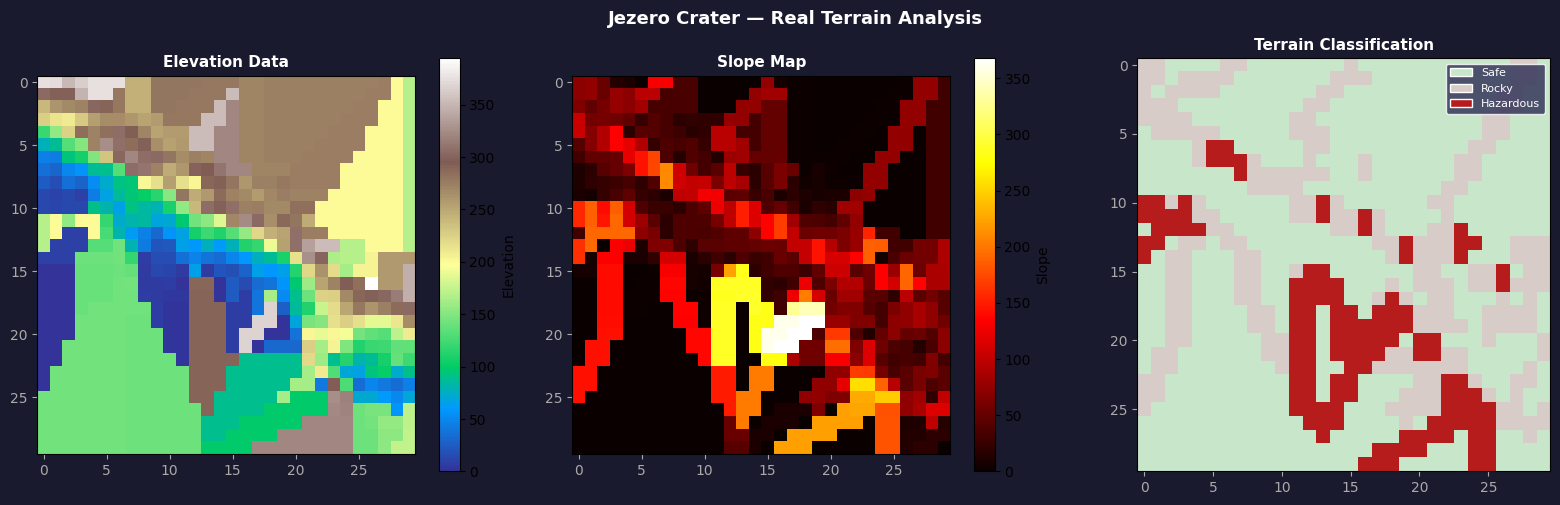

Saved.


In [ ]:
COLOUR_ARRAY = np.array([
    [200, 230, 201],  # SAFE      — green
    [215, 204, 200],  # ROCKY     — grey
    [183,  28,  28],  # HAZARDOUS — red
], dtype=np.uint8)

def terrain_rgb(grid):
    rgb = np.zeros((*grid.shape, 3), dtype=np.uint8)
    for i, c in enumerate(COLOUR_ARRAY):
        rgb[grid == i] = c
    return rgb


fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#1A1A2E')
fig.suptitle('Jezero Crater — Real Terrain Analysis', color='white',
             fontsize=13, fontweight='bold')

# Elevation heatmap
ax1 = axes[0]
ax1.set_facecolor('#12122A')
im1 = ax1.imshow(elevation_grid, cmap='terrain', origin='upper')
plt.colorbar(im1, ax=ax1, label='Elevation')
ax1.set_title('Elevation Data', color='white', fontsize=11, fontweight='bold')
ax1.tick_params(colors='#AAAAAA')

# Slope heatmap
ax2 = axes[1]
ax2.set_facecolor('#12122A')
im2 = ax2.imshow(slope_grid, cmap='hot', origin='upper')
plt.colorbar(im2, ax=ax2, label='Slope')
ax2.set_title('Slope Map', color='white', fontsize=11, fontweight='bold')
ax2.tick_params(colors='#AAAAAA')

# Terrain classification
ax3 = axes[2]
ax3.set_facecolor('#12122A')
ax3.imshow(terrain_rgb(terrain_grid), origin='upper', interpolation='nearest')
legend_elements = [
    mpatches.Patch(facecolor='#C8E6C9', edgecolor='white', label='Safe'),
    mpatches.Patch(facecolor='#D7CCC8', edgecolor='white', label='Rocky'),
    mpatches.Patch(facecolor='#B71C1C', edgecolor='white', label='Hazardous'),
]
ax3.legend(handles=legend_elements, loc='upper right',
           facecolor='#2C2C54', edgecolor='white', labelcolor='white', fontsize=8)
ax3.set_title('Terrain Classification', color='white', fontsize=11, fontweight='bold')
ax3.tick_params(colors='#AAAAAA')

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/figures/nb07_terrain_analysis.png',
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('Saved.')


##  Step 5 — A* on Real Terrain

In [ ]:
def astar(grid, cost_map, start, goal):
    rows, cols = grid.shape
    open_set   = []
    heapq.heappush(open_set, (0, 0, start))
    g_score   = {start: 0}
    came_from = {}
    visited   = set()

    def h(a, b): return abs(a[0]-b[0]) + abs(a[1]-b[1])

    while open_set:
        f, g, cur = heapq.heappop(open_set)
        if cur in visited: continue
        visited.add(cur)
        if cur == goal:
            path = []
            node = goal
            while node in came_from:
                path.append(node)
                node = came_from[node]
            path.append(start)
            path.reverse()
            return path, g_score[goal]
        for dx, dy in [(-1,0),(1,0),(0,-1),(0,1)]:
            nx, ny = cur[0]+dx, cur[1]+dy
            if 0 <= nx < rows and 0 <= ny < cols and grid[nx][ny] != HAZARDOUS:
                nb = (nx, ny)
                tg = g_score[cur] + cost_map[nx][ny]
                if tg < g_score.get(nb, float('inf')):
                    came_from[nb] = cur
                    g_score[nb]   = tg
                    heapq.heappush(open_set, (tg + h(nb, goal), tg, nb))
    return None, float('inf')


# Define start and goal on the real terrain grid
START = (2, 2)
GOAL  = (27, 27)

path, cost = astar(terrain_grid, cost_map, START, GOAL)

if path:
    safe_steps  = sum(1 for c in path if terrain_grid[c[0]][c[1]] == SAFE)
    rocky_steps = sum(1 for c in path if terrain_grid[c[0]][c[1]] == ROCKY)
    print(f'Path found on real Jezero Crater terrain!')
    print(f'Total steps:  {len(path)}')
    print(f'Total cost:   {cost:.1f}')
    print(f'Safe steps:   {safe_steps}')
    print(f'Rocky steps:  {rocky_steps}')
else:
    print('No path found — adjust START/GOAL or thresholds.')

Path found on real Jezero Crater terrain!
Total steps:  55
Total cost:   78.0
Safe steps:   48
Rocky steps:  7



##  Step 6 — Visualise Path on Real Terrain

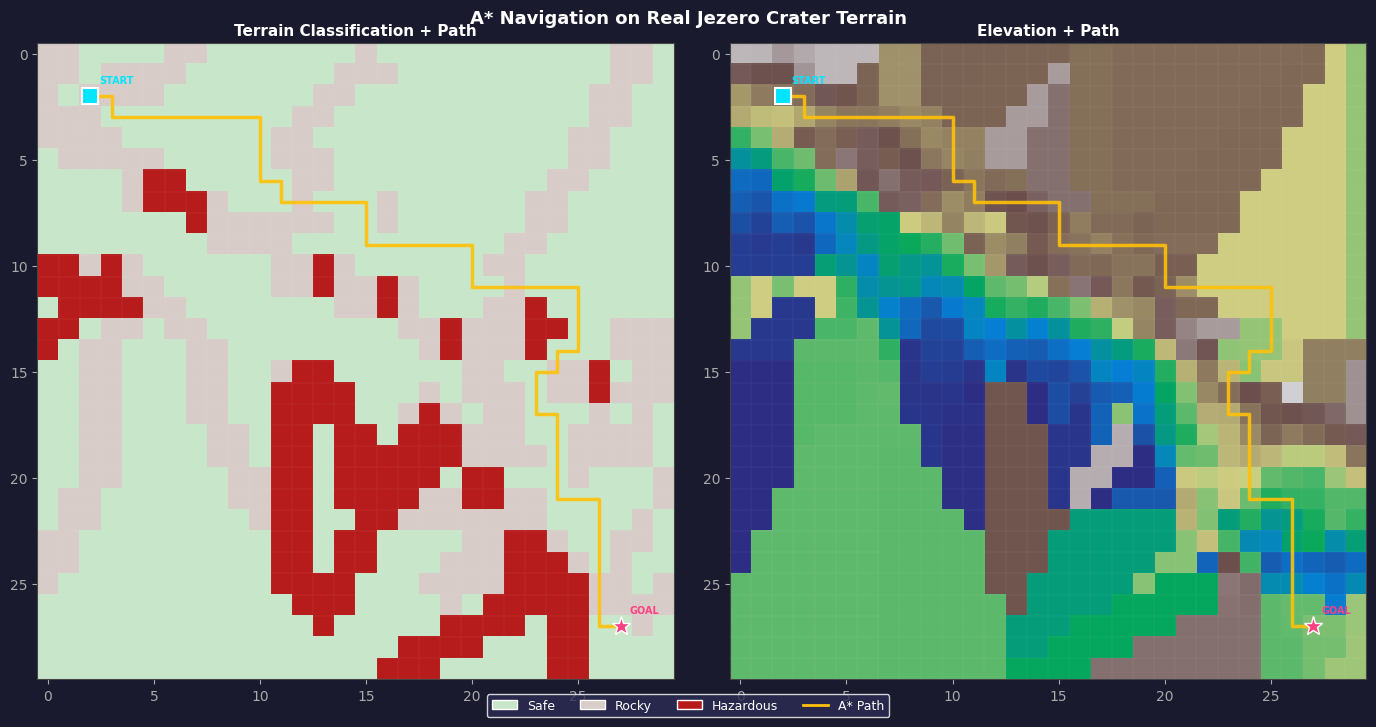

Saved.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.patch.set_facecolor('#1A1A2E')
fig.suptitle('A* Navigation on Real Jezero Crater Terrain',
             color='white', fontsize=13, fontweight='bold')

for ax, (title, show_elev) in zip(axes, [
    ('Terrain Classification + Path', False),
    ('Elevation + Path', True)
]):
    ax.set_facecolor('#1A1A2E')

    if show_elev:
        ax.imshow(elevation_grid, cmap='terrain', origin='upper', alpha=0.8)
    else:
        ax.imshow(terrain_rgb(terrain_grid), origin='upper', interpolation='nearest')

    # Grid lines
    for x in range(GRID_SIZE+1): ax.axvline(x-0.5, color='white', linewidth=0.2, alpha=0.2)
    for y in range(GRID_SIZE+1): ax.axhline(y-0.5, color='white', linewidth=0.2, alpha=0.2)

    # Path
    if path:
        ax.plot([p[1] for p in path], [p[0] for p in path],
                color='#FFC107', linewidth=2.5, zorder=3, alpha=0.9)

    # Start & Goal
    ax.plot(START[1], START[0], 's', color='#00E5FF', markersize=12,
            zorder=5, markeredgecolor='white', markeredgewidth=1.5)
    ax.plot(GOAL[1],  GOAL[0],  '*', color='#FF4081', markersize=14,
            zorder=5, markeredgecolor='white', markeredgewidth=1)
    ax.text(START[1]+0.4, START[0]-0.6, 'START', color='#00E5FF', fontsize=7, fontweight='bold')
    ax.text(GOAL[1]+0.4,  GOAL[0]-0.6,  'GOAL',  color='#FF4081', fontsize=7, fontweight='bold')

    ax.set_title(title, color='white', fontsize=11, fontweight='bold')
    ax.tick_params(colors='#AAAAAA')
    for spine in ax.spines.values(): spine.set_edgecolor('#444444')

legend_elements = [
    mpatches.Patch(facecolor='#C8E6C9', edgecolor='white', label='Safe'),
    mpatches.Patch(facecolor='#D7CCC8', edgecolor='white', label='Rocky'),
    mpatches.Patch(facecolor='#B71C1C', edgecolor='white', label='Hazardous'),
    plt.Line2D([0],[0], color='#FFC107', linewidth=2, label='A* Path'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4,
           facecolor='#2C2C54', edgecolor='white', labelcolor='white',
           fontsize=9, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/figures/nb07_real_terrain_path.png',
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('Saved.')


## Step 7 — Export Waypoints for Unity

Maps grid coordinates to Unity world coordinates matching the actual OBJ mesh dimensions.

In [ ]:
def export_real_terrain_path(path, terrain_grid, elevation_grid,
                              bounds, grid_size=30):
    """
    Export path waypoints mapped to Unity world coordinates.
    Maps grid (row, col) → Unity (X, Y, Z) using actual OBJ bounds.
    Elevation is included so the rover follows the terrain surface.
    """
    x_range   = bounds['x_max'] - bounds['x_min']
    y_range   = bounds['y_max'] - bounds['y_min']
    elev_min  = bounds['elev_min']
    elev_max  = bounds['elev_max']
    elev_range = elev_max - elev_min

    # Unity scale
    UNITY_SCALE_X = 39900.0
    UNITY_SCALE_Z = 39900.0
    UNITY_SCALE_Y = 7405.87

    OFFSET_X = -39900.0
    OFFSET_Z = -39900.0
    HOVER_HEIGHT = -4367.50

    waypoints = []
    for step_idx, cell in enumerate(path):
        row, col = cell

        # Map grid position to Unity X, Z
        unity_x = (col / grid_size) * UNITY_SCALE_X + OFFSET_X
        unity_z = (row / grid_size) * UNITY_SCALE_Z + OFFSET_Z

        # Map elevation to Unity Y
        elev        = elevation_grid[row][col]
        norm_elev   = (elev - elev_min) / elev_range if elev_range > 0 else 0
        unity_y     = norm_elev * UNITY_SCALE_Y + HOVER_HEIGHT

        terrain_type = int(terrain_grid[row][col])
        terrain_name = {0:'Safe', 1:'Rocky', 2:'Hazardous'}.get(terrain_type, 'Unknown')

        waypoints.append({
            'step':     step_idx,
            'grid_row': int(row),
            'grid_col': int(col),
            'unity_x':  round(unity_x, 3),
            'unity_y':  round(unity_y, 3),
            'unity_z':  round(unity_z, 3),
            'terrain':  terrain_name,
            'elevation':round(float(elev), 4),
            'is_replan': False,
            'severity': 'Clean',
        })

    export_data = {
        'metadata': {
            'total_steps':  len(path),
            'grid_size':    grid_size,
            'unity_scale_x': UNITY_SCALE_X,
            'unity_scale_z': UNITY_SCALE_Z,
            'unity_scale_y': UNITY_SCALE_Y,
            'source': 'real_jezero_crater_terrain',
        },
        'waypoints': waypoints,
        'replan_steps': [],
    }
    return export_data


export_data = export_real_terrain_path(
    path, terrain_grid, elevation_grid, bounds, grid_size=GRID_SIZE
)

EXPORT_PATH = f'{PROJECT_DIR}/path_data.json'
with open(EXPORT_PATH, 'w') as f:
    json.dump(export_data, f, indent=2)

print(f'Path exported successfully!')
print(f'Total waypoints: {len(path)}')
print(f'Saved to: {EXPORT_PATH}')
print(f'\nFirst 3 waypoints:')
for wp in export_data['waypoints'][:3]:
    print(f'  Step {wp["step"]}: Grid({wp["grid_row"]},{wp["grid_col"]}) → '
          f'Unity({wp["unity_x"]}, {wp["unity_y"]}, {wp["unity_z"]}) '
          f'[{wp["terrain"]}] elev={wp["elevation"]:.4f}')

print(f'\nLast waypoint (Goal):')
wp = export_data['waypoints'][-1]
print(f'  Step {wp["step"]}: Unity({wp["unity_x"]}, {wp["unity_y"]}, {wp["unity_z"]})')

Path exported successfully!
Total waypoints: 55
Saved to: /content/drive/MyDrive/Colab Notebooks/Mars Rover Project/path_data.json

First 3 waypoints:
  Step 0: Grid(2,2) → Unity(-37240.0, 600.664, -37240.0) [Rocky] elev=267.6657
  Step 1: Grid(2,3) → Unity(-35910.0, 674.325, -37240.0) [Rocky] elev=271.6343
  Step 2: Grid(3,3) → Unity(-35910.0, -131.96, -35910.0) [Safe] elev=228.1947

Last waypoint (Goal):
  Step 54: Unity(-3990.0, -1476.969, -3990.0)



## Summary


- Real Jezero Crater elevation data parsed from NASA Mars Trek OBJ
- Slope-based terrain classification — steep areas classified as Rocky or Hazardous
- A* navigation on the real terrain cost map
- Waypoints exported in Unity world coordinates matching actual terrain geometry

